# 14. AUC Optimization: Can DrugBank Validation Discrimination Be Improved?

**Purpose:** The DrugBank-validation AUC (log ROR vs DrugBank membership) is 0.514, barely
above chance. This notebook tests whether that can be improved, using several approaches, and
explains the result.

1. **Continuous log(ROR)** as a ranked predictor (this is already what produces 0.514).
2. **Sample-size restriction** (N_EXPOSED >= 10 / 50 / 100) to remove noisy small-N estimates.
3. **Temporal composite scores** that fold in H1/H2 replication (geometric mean, replication weight).
4. **(Sensitivity)** restrict the negative set to drug pairs where both drugs are catalogued in DrugBank.
5. **Alternative single-variable scores** already in the pipeline (CI lower bound, chi-square, sample size, percent serious).
6. **Multivariate logistic combination** of FAERS features, cross-validated.

**Bottom line (see results):** the only thing that lifts the AUC is sample size (N_EXPOSED, ~0.62),
which reflects drug popularity and reporting volume rather than interaction biology. Every measure
of interaction strength stays near chance. Known DrugBank DDIs have a median ROR of ~1.93,
statistically indistinguishable from non-DrugBank pairs. FAERS disproportionality (pharmacodynamic
ADE signals) and DrugBank (a pharmacokinetic interaction catalog) capture different, complementary
kinds of interaction, so ROR magnitude cannot rank DrugBank membership.

**Data dependencies (CSVs only, no kernel state):**
- `../data/signals/FAERS_DDI_ROR_ALL.csv`
- `../data/raw/DRUGBANK_DDI_REFERENCE.csv`
- `../results/FAERS_TEMPORAL_STABILITY.csv`


In [1]:
import re
import numpy as np
import pandas as pd
from sklearn.metrics import roc_curve, auc, roc_auc_score
import matplotlib.pyplot as plt

SALTS = ['HYDROCHLORIDE', 'SODIUM', 'PHOSPHATE', 'SULFATE', 'POTASSIUM',
         'BESYLATE', 'MALEATE', 'FUMARATE', 'MESYLATE', 'ACETATE',
         'DISODIUM', 'CALCIUM', 'OXIDE', 'CITRATE']
_SALT_RE = re.compile(r'\s*(' + '|'.join(SALTS) + r')\s*$')

def std_name(x):
    if pd.isna(x):
        return None
    x = str(x).upper().strip()
    prev = None
    while prev != x:
        prev = x
        x = _SALT_RE.sub('', x).strip()
    return x

def std_series(s):
    uniq = pd.Series(s.dropna().unique())
    mapping = {v: std_name(v) for v in uniq}
    return s.map(mapping)

def roc_auc_safe(labels, scores):
    mask = (~pd.isna(scores)) & (~pd.isna(labels))
    labels = np.asarray(labels)[mask.values]
    scores = np.asarray(scores)[mask.values]
    if len(np.unique(labels)) < 2:
        return np.nan, None, None
    fpr, tpr, _ = roc_curve(labels, scores)
    return auc(fpr, tpr), fpr, tpr

print("=" * 60); print("LOADING DATA"); print("=" * 60)
ror = pd.read_csv("../data/signals/FAERS_DDI_ROR_ALL.csv")
print(f"{len(ror):,} rows (ROR ALL)")
db = pd.read_csv("../data/raw/DRUGBANK_DDI_REFERENCE.csv", usecols=['DRUG_A', 'DRUG_B'])
print(f"{len(db):,} rows (DrugBank reference)")

split = ror['PAIR'].str.split(r'\s*\+\s*', n=1, expand=True)
ror['DRUG_A'] = split[0]; ror['DRUG_B'] = split[1]

print("Standardizing drug names (salt stripping)...")
ror['DRUG_A_STD'] = std_series(ror['DRUG_A'])
ror['DRUG_B_STD'] = std_series(ror['DRUG_B'])
db['DRUG_A_STD'] = std_series(db['DRUG_A'])
db['DRUG_B_STD'] = std_series(db['DRUG_B'])

faers_drugs = {d for d in set(ror['DRUG_A_STD']).union(set(ror['DRUG_B_STD'])) if pd.notna(d)}
db_f = db[db['DRUG_A_STD'].isin(faers_drugs) & db['DRUG_B_STD'].isin(faers_drugs)]
db_pairs = set()
for a, b in zip(db_f['DRUG_A_STD'], db_f['DRUG_B_STD']):
    if pd.notna(a) and pd.notna(b):
        db_pairs.add((a, b)); db_pairs.add((b, a))

ror['IN_DB'] = [(a, b) in db_pairs if (pd.notna(a) and pd.notna(b)) else False
                for a, b in zip(ror['DRUG_A_STD'], ror['DRUG_B_STD'])]
ror['LOG_ROR'] = np.log10(ror['ROR'])
print(f"Unique FAERS drugs: {len(faers_drugs):,}")
print(f"DrugBank DDIs in FAERS pair universe (positives): {ror['IN_DB'].sum():,} / {len(ror):,}")

results = []
roc_curves = {}  # curated set for the ROC overlay

LOADING DATA
226,153 rows (ROR ALL)


1,455,276 rows (DrugBank reference)
Standardizing drug names (salt stripping)...


Unique FAERS drugs: 4,596
DrugBank DDIs in FAERS pair universe (positives): 40,790 / 226,153


## Approach 1: Continuous log(ROR) as a ranked predictor

This is what already produced the reported 0.514. The ROC already varies the threshold across the
full continuous range of log(ROR); there is no separate "binary" version to upgrade from.

In [2]:
a1, f1, t1 = roc_auc_safe(ror['IN_DB'], ror['LOG_ROR'])
print(f"AUC (log ROR, full universe N>=10): {a1:.4f}   "
      f"[{len(ror):,} pairs, {ror['IN_DB'].sum():,} positives]")
results.append(dict(Approach="1. Continuous log(ROR)", Variant="Full universe (N>=10)",
                    N_pairs=len(ror), N_positives=int(ror['IN_DB'].sum()), AUC=round(a1, 4)))
roc_curves[f"Current method: log(ROR) (AUC={a1:.3f})"] = (f1, t1)

AUC (log ROR, full universe N>=10): 0.5146   [226,153 pairs, 40,790 positives]


## Approach 2: Restrict to larger sample size

Hypothesis: small-N pairs have noisy ROR estimates that hurt discrimination. Recompute AUC at
N_EXPOSED >= 10 / 50 / 100.

In [3]:
for n_min in [10, 50, 100]:
    sub = ror[ror['N_EXPOSED'] >= n_min]
    a, f, t = roc_auc_safe(sub['IN_DB'], sub['LOG_ROR'])
    print(f"N >= {n_min:<4d}: AUC = {a:.4f}   [{len(sub):,} pairs, {sub['IN_DB'].sum():,} positives]")
    results.append(dict(Approach="2. Sample-size restriction", Variant=f"N >= {n_min}",
                        N_pairs=len(sub), N_positives=int(sub['IN_DB'].sum()), AUC=round(a, 4)))

N >= 10  : AUC = 0.5021   [182,930 pairs, 36,925 positives]
N >= 50  : AUC = 0.4819   [34,898 pairs, 10,152 positives]
N >= 100 : AUC = 0.4861   [14,944 pairs, 4,889 positives]


## Approach 3: Temporal composite scores

Fold H1/H2 replication into the score. Baseline = overall log(ROR) on the same temporal subset so the
comparison isolates the composite's effect. Geometric mean = sqrt(ROR_H1 * ROR_H2).
Replication weight = 1.0 if signal in both halves, 0.5 if one, 0.25 if neither.

In [4]:
temporal = pd.read_csv("../results/FAERS_TEMPORAL_STABILITY.csv")
merged = temporal.merge(ror[['PAIR', 'IN_DB', 'ROR', 'LOG_ROR']], on='PAIR', how='inner')
print(f"Temporal subset: {len(merged):,} pairs, {merged['IN_DB'].sum():,} positives")
h1 = merged['ROR_H1'].clip(lower=0.01); h2 = merged['ROR_H2'].clip(lower=0.01)

ab, fb, tb = roc_auc_safe(merged['IN_DB'], merged['LOG_ROR'])
print(f"Baseline log(ROR), temporal subset:  AUC = {ab:.4f}")
results.append(dict(Approach="3. Temporal composite", Variant="Baseline log(ROR), temporal subset",
                    N_pairs=len(merged), N_positives=int(merged['IN_DB'].sum()), AUC=round(ab, 4)))

merged['GEOM_MEAN'] = np.sqrt(h1 * h2)
ag, fg, tg = roc_auc_safe(merged['IN_DB'], np.log10(merged['GEOM_MEAN']))
print(f"Geometric mean sqrt(ROR_H1*ROR_H2):  AUC = {ag:.4f}")
results.append(dict(Approach="3. Temporal composite", Variant="Geometric mean of H1/H2 ROR",
                    N_pairs=len(merged), N_positives=int(merged['IN_DB'].sum()), AUC=round(ag, 4)))

rep = merged['SIGNAL_H1'].astype(int) + merged['SIGNAL_H2'].astype(int)
weight = rep.map({2: 1.0, 1: 0.5, 0: 0.25})
ar, fr, tr = roc_auc_safe(merged['IN_DB'], merged['LOG_ROR'] * weight)
print(f"Replication-weighted log(ROR):       AUC = {ar:.4f}")
print(f"   (both-halves n={int((rep==2).sum()):,}, one-half n={int((rep==1).sum()):,}, "
      f"neither n={int((rep==0).sum()):,})")
results.append(dict(Approach="3. Temporal composite", Variant="Replication-weighted log(ROR)",
                    N_pairs=len(merged), N_positives=int(merged['IN_DB'].sum()), AUC=round(ar, 4)))

Temporal subset: 70,901 pairs, 17,798 positives
Baseline log(ROR), temporal subset:  AUC = 0.4944
Geometric mean sqrt(ROR_H1*ROR_H2):  AUC = 0.4924
Replication-weighted log(ROR):       AUC = 0.4996
   (both-halves n=17,819, one-half n=18,023, neither n=35,059)


## Approach 4 (sensitivity): restrict negatives to DrugBank-catalogued drugs

A pair "not in DrugBank" is only a true negative if both drugs are actually catalogued in DrugBank.
Restrict the universe to pairs where both drugs appear in at least one DrugBank interaction.

In [5]:
db_drugs = {d for d in set(db_f['DRUG_A_STD']).union(set(db_f['DRUG_B_STD'])) if pd.notna(d)}
cov = ror[ror['DRUG_A_STD'].isin(db_drugs) & ror['DRUG_B_STD'].isin(db_drugs)]
a4, f4, t4 = roc_auc_safe(cov['IN_DB'], cov['LOG_ROR'])
print(f"Catalogued-drug universe ({len(db_drugs):,} drugs): AUC = {a4:.4f}   "
      f"[{len(cov):,} pairs, {cov['IN_DB'].sum():,} positives]")
results.append(dict(Approach="4. Catalogued-drug universe", Variant="Both drugs in DrugBank",
                    N_pairs=len(cov), N_positives=int(cov['IN_DB'].sum()), AUC=round(a4, 4)))

Catalogued-drug universe (1,430 drugs): AUC = 0.4805   [74,693 pairs, 40,790 positives]


## Approach 5: Alternative single-variable scores

Other columns already computed in the pipeline can be used as ranking scores instead of log(ROR):
the lower bound of the confidence interval (precision-aware), the chi-square statistic (magnitude
times sample size), the raw exposed sample size, and the percent-serious rate. This shows whether a
different existing quantity discriminates DrugBank membership better than ROR.

In [6]:
ror['PCT_SERIOUS'] = ror['A_SERIOUS_EXPOSED'] / ror['N_EXPOSED']
ror['CI_WIDTH'] = np.log10(ror['CI_UPPER'].clip(lower=1e-6)) - np.log10(ror['CI_LOWER'].clip(lower=1e-6))

alt_scores = {
    "CI lower bound": ror['CI_LOWER'],
    "Chi-square statistic": ror['CHI2'],
    "Sample size (N_EXPOSED)": ror['N_EXPOSED'],
    "Percent serious": ror['PCT_SERIOUS'],
}
for name, score in alt_scores.items():
    a, f, t = roc_auc_safe(ror['IN_DB'], score)
    print(f"{name:28s}: AUC = {a:.4f}")
    results.append(dict(Approach="5. Alternative single scores", Variant=name,
                        N_pairs=len(ror), N_positives=int(ror['IN_DB'].sum()), AUC=round(a, 4)))
    if name.startswith("Sample size"):
        roc_curves[f"Best single: sample size (AUC={a:.3f})"] = (f, t)

CI lower bound              : AUC = 0.5711
Chi-square statistic        : AUC = 0.5754
Sample size (N_EXPOSED)     : AUC = 0.6204
Percent serious             : AUC = 0.5130


## Approach 6: Multivariate logistic combination (cross-validated)

Combine the FAERS features (log ROR, log sample size, CI width, percent serious) in a logistic
regression and evaluate with 5-fold cross-validation. This is the strongest principled way to
maximize discrimination. We then inspect the standardized coefficients to see which feature drives
the result.

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_predict, StratifiedKFold

feat = pd.DataFrame({
    'LOG_ROR': ror['LOG_ROR'],
    'LOG_N': np.log10(ror['N_EXPOSED'].clip(lower=1)),
    'CI_WIDTH': ror['CI_WIDTH'],
    'PCT_SERIOUS': ror['PCT_SERIOUS'],
}).replace([np.inf, -np.inf], np.nan)
y = ror['IN_DB'].astype(int)
mask = feat.notna().all(axis=1)
X = feat[mask]; yv = y[mask]

pipe = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000))
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
proba = cross_val_predict(pipe, X, yv, cv=cv, method='predict_proba')[:, 1]
a6 = roc_auc_score(yv, proba)
f6, t6, _ = roc_curve(yv, proba)
print(f"Multivariate logistic (5-fold CV): AUC = {a6:.4f}   [{len(X):,} pairs]")
results.append(dict(Approach="6. Multivariate logistic", Variant="log(ROR)+log(N)+CI width+%serious (5-fold CV)",
                    N_pairs=int(len(X)), N_positives=int(yv.sum()), AUC=round(a6, 4)))
roc_curves[f"Multivariate combo (AUC={a6:.3f})"] = (f6, t6)

# Which feature drives it? Standardized coefficients (larger magnitude = more influence).
pipe.fit(X, yv)
coefs = pipe.named_steps['logisticregression'].coef_[0]
print("\nStandardized logistic coefficients:")
for nm, c in sorted(zip(X.columns, coefs), key=lambda kv: -abs(kv[1])):
    print(f"   {nm:14s}: {c:+.3f}")

Multivariate logistic (5-fold CV): AUC = 0.6215   [226,153 pairs]

Standardized logistic coefficients:
   LOG_N         : +0.376
   PCT_SERIOUS   : +0.285
   LOG_ROR       : -0.252
   CI_WIDTH      : -0.046


/Users/joshbuck/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/joshbuck/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/joshbuck/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/joshbuck/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/joshbuck/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/joshbuck/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning:

## Diagnostic: why ROR cannot rank DrugBank membership

The reason every interaction-strength score lands near 0.5: the ROR distributions of known vs
unknown pairs almost completely overlap.

In [8]:
known = ror.loc[ror['IN_DB'], 'ROR']; unknown = ror.loc[~ror['IN_DB'], 'ROR']
print(f"Known DDIs (IN_DB):  median ROR = {known.median():.3f}, mean = {known.mean():.3f}")
print(f"Not-in-DrugBank:     median ROR = {unknown.median():.3f}, mean = {unknown.mean():.3f}")
print(f"Known DDIs with ROR < 2.0 (below signal threshold): {(known < 2.0).mean()*100:.1f}%")
print(f"Known DDIs with ROR < 1.0 (no disproportionality):  {(known < 1.0).mean()*100:.1f}%")

Known DDIs (IN_DB):  median ROR = 1.933, mean = 4.783
Not-in-DrugBank:     median ROR = 1.795, mean = 5.423
Known DDIs with ROR < 2.0 (below signal threshold): 52.1%
Known DDIs with ROR < 1.0 (no disproportionality):  25.0%


## Summary table and figure

                    Approach                                       Variant  N_pairs  N_positives    AUC
      1. Continuous log(ROR)                         Full universe (N>=10)   226153        40790 0.5146
  2. Sample-size restriction                                       N >= 10   182930        36925 0.5021
  2. Sample-size restriction                                       N >= 50    34898        10152 0.4819
  2. Sample-size restriction                                      N >= 100    14944         4889 0.4861
       3. Temporal composite            Baseline log(ROR), temporal subset    70901        17798 0.4944
       3. Temporal composite                   Geometric mean of H1/H2 ROR    70901        17798 0.4924
       3. Temporal composite                 Replication-weighted log(ROR)    70901        17798 0.4996
 4. Catalogued-drug universe                        Both drugs in DrugBank    74693        40790 0.4805
5. Alternative single scores                                CI l

Saved: ../figures/thesis/fig_auc_optimization.png


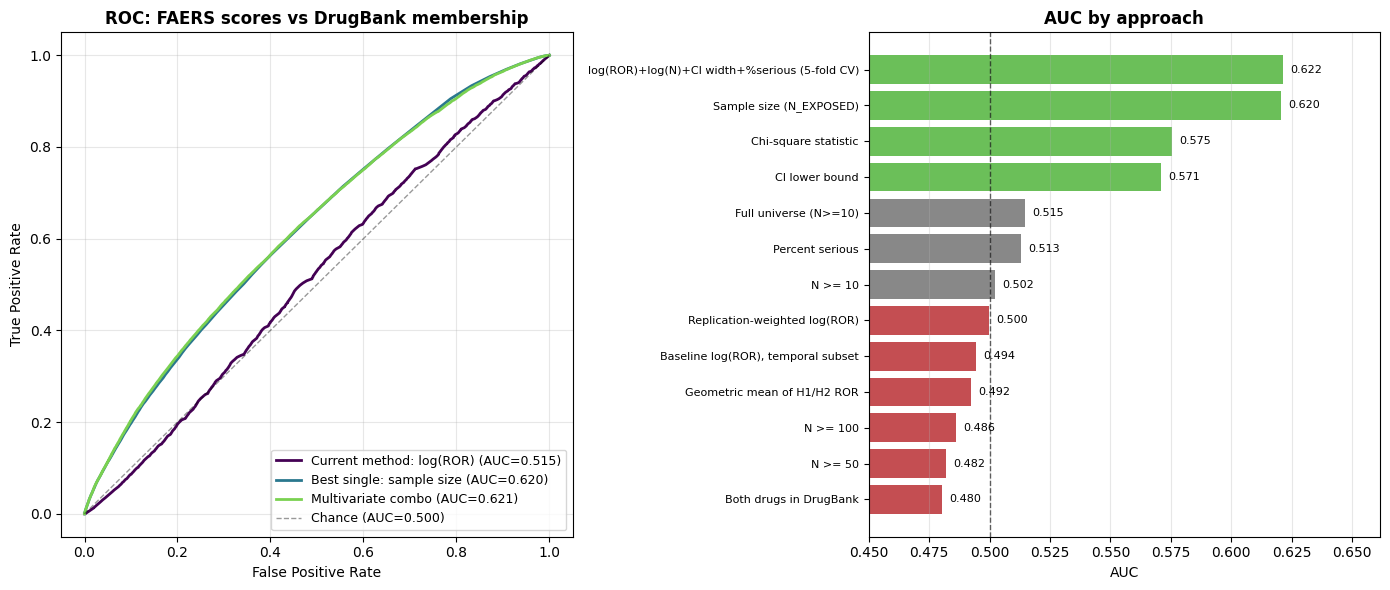

In [9]:
summary = pd.DataFrame(results)
summary.to_csv("../results/FAERS_AUC_OPTIMIZATION_SUMMARY.csv", index=False)
print(summary.to_string(index=False))
print("\nSaved: ../results/FAERS_AUC_OPTIMIZATION_SUMMARY.csv")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
colors = plt.cm.viridis(np.linspace(0, 0.8, len(roc_curves)))
for (label, (fpr, tpr)), c in zip(roc_curves.items(), colors):
    if fpr is not None:
        ax1.plot(fpr, tpr, lw=2, label=label, color=c)
ax1.plot([0, 1], [0, 1], 'k--', alpha=0.4, lw=1, label='Chance (AUC=0.500)')
ax1.set_xlabel('False Positive Rate'); ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC: FAERS scores vs DrugBank membership', fontweight='bold')
ax1.legend(loc='lower right', fontsize=9); ax1.grid(alpha=0.3)

order = summary.sort_values('AUC').reset_index(drop=True)
bar_colors = ['#6BBF59' if v >= 0.55 else ('#C44E52' if v < 0.50 else '#888888') for v in order['AUC']]
ax2.barh(range(len(order)), order['AUC'], color=bar_colors)
ax2.axvline(0.5, color='k', ls='--', alpha=0.6, lw=1)
ax2.set_yticks(range(len(order))); ax2.set_yticklabels(order['Variant'], fontsize=8)
ax2.set_xlabel('AUC'); ax2.set_xlim(0.45, max(0.66, order['AUC'].max() + 0.04))
ax2.set_title('AUC by approach', fontweight='bold')
for i, v in enumerate(order['AUC']):
    ax2.text(v + 0.003, i, f"{v:.3f}", va='center', fontsize=8)
ax2.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig("../figures/thesis/fig_auc_optimization.png", dpi=300, bbox_inches='tight')
print("Saved: ../figures/thesis/fig_auc_optimization.png")
plt.show()

## Conclusion

No measure of interaction strength improves discrimination above chance. The only score that lifts
the AUC is sample size (N_EXPOSED, AUC ~0.62), and the multivariate model's discrimination is driven
almost entirely by that same sample-size term. Sample size reflects how commonly a pair is
co-reported, which tracks drug popularity and prescribing volume, not interaction biology, so the
lift is a confound rather than a genuine validation gain. Chasing a higher AUC this way would make
the validation less honest, not more.

The diagnostic explains the mechanism: known DrugBank DDIs have a median ROR of ~1.93 (about half
below the signal threshold of 2.0; a quarter below 1.0), so their ROR distribution overlaps almost
entirely with non-DrugBank pairs. No monotone transform of ROR can separate them, because FAERS
disproportionality detects pharmacodynamic safety signals while DrugBank catalogs pharmacokinetic
interactions, and the two only partly overlap.

The appropriate summary for the manuscript is therefore the operating-point validation (sensitivity,
specificity, PPV, NPV at the ROR > 2 threshold and the 2x2 table), with the ROC/AUC reported as a
secondary diagnostic that demonstrates complementarity rather than as the headline performance
metric.